<a href="https://colab.research.google.com/github/Sareido/TP_Prediction_Annulation_Hotel/blob/main/Examen_Final_Pratie_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Examen Final -Pratie Pratique

Exercice 1 : Classification - Arbre de décision

Question 1 - Développement du modèle et accuracy sur le training set

In [3]:
#Import des bibliothèques nécessaires
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans



In [6]:
# 1. Dataset Arbre de décision
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'AgeRange': ['Young', 'Middle-aged', 'Old', 'Middle-aged', 'Old', 'Young', 'Middle-aged', 'Old'],
    'Occupation': ['Tutor', 'Professor', 'Tutor', 'professor', 'Tutor', 'Lecturer', 'lecturer', 'Tutor'],
    'Gender': ['F', 'F', 'M', 'M', 'F', 'M', 'F', 'F'],
    'Happy': ['Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No']
}
df = pd.DataFrame(data)
print("Dataset original :")
print(df)
print()



Dataset original :
   ID     AgeRange Occupation Gender Happy
0   1        Young      Tutor      F   Yes
1   2  Middle-aged  Professor      F    No
2   3          Old      Tutor      M   Yes
3   4  Middle-aged  professor      M   Yes
4   5          Old      Tutor      F   Yes
5   6        Young   Lecturer      M    No
6   7  Middle-aged   lecturer      F    No
7   8          Old      Tutor      F    No



In [5]:
# Normalisation Occupation
df['Occupation'] = df['Occupation'].str.lower().str.capitalize()
print(df)

   ID     AgeRange Occupation Gender Happy
0   1        Young      Tutor      F   Yes
1   2  Middle-aged  Professor      F    No
2   3          Old      Tutor      M   Yes
3   4  Middle-aged  Professor      M   Yes
4   5          Old      Tutor      F   Yes
5   6        Young   Lecturer      M    No
6   7  Middle-aged   Lecturer      F    No
7   8          Old      Tutor      F    No


In [7]:
# Encodage des variables catégorielles
le_age = LabelEncoder()
le_occ = LabelEncoder()
le_gen = LabelEncoder()
le_happy = LabelEncoder()

df['AgeRange_enc'] = le_age.fit_transform(df['AgeRange'])
df['Occupation_enc'] = le_occ.fit_transform(df['Occupation'])
df['Gender_enc'] = le_gen.fit_transform(df['Gender'])
df['Happy_enc'] = le_happy.fit_transform(df['Happy'])

print("Classes AgeRange :", list(le_age.classes_))
print("Classes Occupation :", list(le_occ.classes_))
print("Classes Gender :", list(le_gen.classes_))
print("Classes Happy :", list(le_happy.classes_))
print()

Classes AgeRange : ['Middle-aged', 'Old', 'Young']
Classes Occupation : ['Lecturer', 'Professor', 'Tutor', 'lecturer', 'professor']
Classes Gender : ['F', 'M']
Classes Happy : ['No', 'Yes']



In [8]:
# Séparation features / target
X = df[['AgeRange_enc', 'Occupation_enc', 'Gender_enc']]
y = df['Happy_enc']

print("Features (X) :")
print(X)
print("\nTarget (y) :")
print(y)

Features (X) :
   AgeRange_enc  Occupation_enc  Gender_enc
0             2               2           0
1             0               1           0
2             1               2           1
3             0               4           1
4             1               2           0
5             2               0           1
6             0               3           0
7             1               2           0

Target (y) :
0    1
1    0
2    1
3    1
4    1
5    0
6    0
7    0
Name: Happy_enc, dtype: int64


In [9]:
# Création et entraînement du modèle Arbre de décision
# On utilise le critère 'entropy' (gain d'information) comme vu en cours
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# Prédictions sur le training set
y_pred = clf.predict(X)

# Calcul de l'accuracy
acc = accuracy_score(y, y_pred)
print(f"Accuracy sur le dataset de training : {acc:.4f} ({acc*100:.1f}%)")

Accuracy sur le dataset de training : 0.8750 (87.5%)


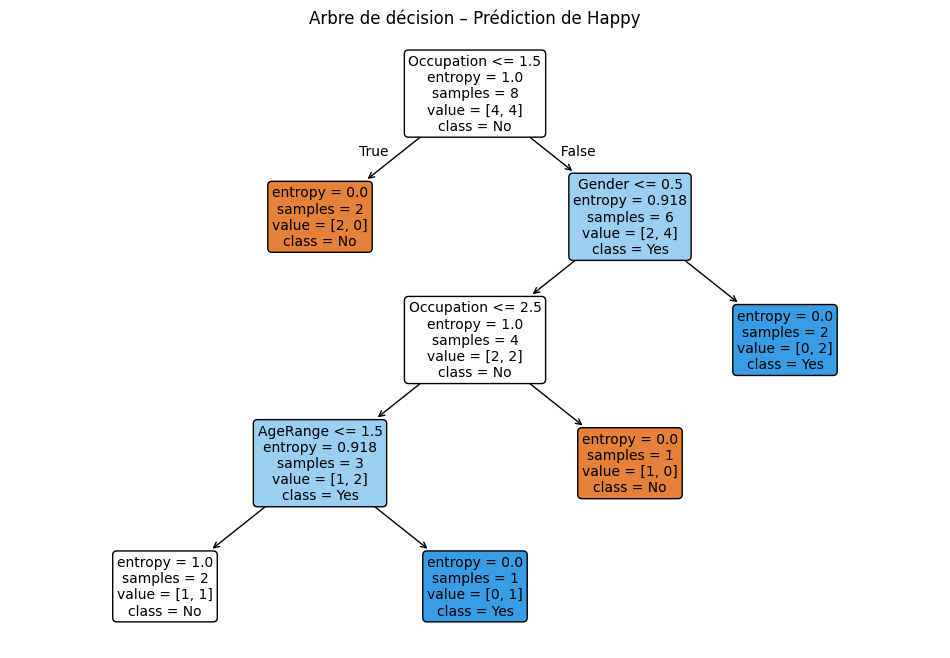


Représentation textuelle de l'arbre :
|--- Occupation <= 1.50
|   |--- class: 0
|--- Occupation >  1.50
|   |--- Gender <= 0.50
|   |   |--- Occupation <= 2.50
|   |   |   |--- AgeRange <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- AgeRange >  1.50
|   |   |   |   |--- class: 1
|   |   |--- Occupation >  2.50
|   |   |   |--- class: 0
|   |--- Gender >  0.50
|   |   |--- class: 1



In [10]:
# Visualisation de l'arbre
plt.figure(figsize=(12, 8))
plot_tree(clf,
          feature_names=['AgeRange', 'Occupation', 'Gender'],
          class_names=list(le_happy.classes_),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Arbre de décision – Prédiction de Happy")
plt.show()

# Affichage textuel de l'arbre
print("\nReprésentation textuelle de l'arbre :")
print(export_text(clf, feature_names=['AgeRange', 'Occupation', 'Gender']))

Questiton 2 - Prédiction pour un nouvel individu

In [11]:
# Préparation de la nouvelle observation
new_person = {
    'AgeRange': 'Young',          # 'young' → 'Young'
    'Occupation': 'Professor',    # 'professor' → 'Professor' (après normalisation)
    'Gender': 'F'
}

# Encodage avec les mêmes LabelEncoders
age_enc = le_age.transform([new_person['AgeRange']])[0]
occ_enc = le_occ.transform([new_person['Occupation']])[0]
gen_enc = le_gen.transform([new_person['Gender']])[0]

X_new = [[age_enc, occ_enc, gen_enc]]
print("Nouvelle observation encodée :", X_new)
print(f"  AgeRange='{new_person['AgeRange']}' → {age_enc}")
print(f"  Occupation='{new_person['Occupation']}' → {occ_enc}")
print(f"  Gender='{new_person['Gender']}' → {gen_enc}")



Nouvelle observation encodée : [[np.int64(2), np.int64(1), np.int64(0)]]
  AgeRange='Young' → 2
  Occupation='Professor' → 1
  Gender='F' → 0


In [12]:
# Prédiction
pred_enc = clf.predict(X_new)[0]
pred_label = le_happy.inverse_transform([pred_enc])[0]

print(f"\n→ Prédiction : Happy = {pred_label}")


→ Prédiction : Happy = No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Exercice 2: Clustering K-Means**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [14]:
# Dataset clients
clients = pd.DataFrame({
    'ClientID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': [25, 45, 32, 51, 23, 60, 29, 55, 38, 47],
    'RevenuAnnuel_k$': [40, 42, 60, 65, 70, 71, 85, 88, 95, 100],
    'ScoreDepense': [75, 30, 55, 20, 88, 15, 90, 18, 60, 25]
})
print(clients)

   ClientID  Age  RevenuAnnuel_k$  ScoreDepense
0         1   25               40            75
1         2   45               42            30
2         3   32               60            55
3         4   51               65            20
4         5   23               70            88
5         6   60               71            15
6         7   29               85            90
7         8   55               88            18
8         9   38               95            60
9        10   47              100            25


**Question 1**

In [15]:
from sklearn.cluster import KMeans
import numpy as np
# a_ Appliquer l'algorithme K-Means sur les variables RevenuAnnuel_k$ et ScoreDepense, avec k = 3
# Sélection des variables pour le clustering
X_kmeans = clients[['RevenuAnnuel_k$', 'ScoreDepense']].values
print("Données utilisées pour K-Means :")
print(X_kmeans)

Données utilisées pour K-Means :
[[ 40  75]
 [ 42  30]
 [ 60  55]
 [ 65  20]
 [ 70  88]
 [ 71  15]
 [ 85  90]
 [ 88  18]
 [ 95  60]
 [100  25]]


In [16]:
# Application de K-Means avec k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_kmeans)

clients['Cluster'] = labels
print("Attribution des clusters :")
print(clients[['ClientID', 'RevenuAnnuel_k$', 'ScoreDepense', 'Cluster']])


Attribution des clusters :
   ClientID  RevenuAnnuel_k$  ScoreDepense  Cluster
0         1               40            75        0
1         2               42            30        0
2         3               60            55        0
3         4               65            20        1
4         5               70            88        2
5         6               71            15        1
6         7               85            90        2
7         8               88            18        1
8         9               95            60        2
9        10              100            25        1


In [17]:
# b) Coordonnées des centroïdes
centroids = kmeans.cluster_centers_
print("Coordonnées des 3 centroïdes :")
for i, c in enumerate(centroids):
    print(f"  Cluster {i} : RevenuAnnuel_k$ = {c[0]:.2f}, ScoreDepense = {c[1]:.2f}")

Coordonnées des 3 centroïdes :
  Cluster 0 : RevenuAnnuel_k$ = 47.33, ScoreDepense = 53.33
  Cluster 1 : RevenuAnnuel_k$ = 81.00, ScoreDepense = 19.50
  Cluster 2 : RevenuAnnuel_k$ = 83.33, ScoreDepense = 79.33


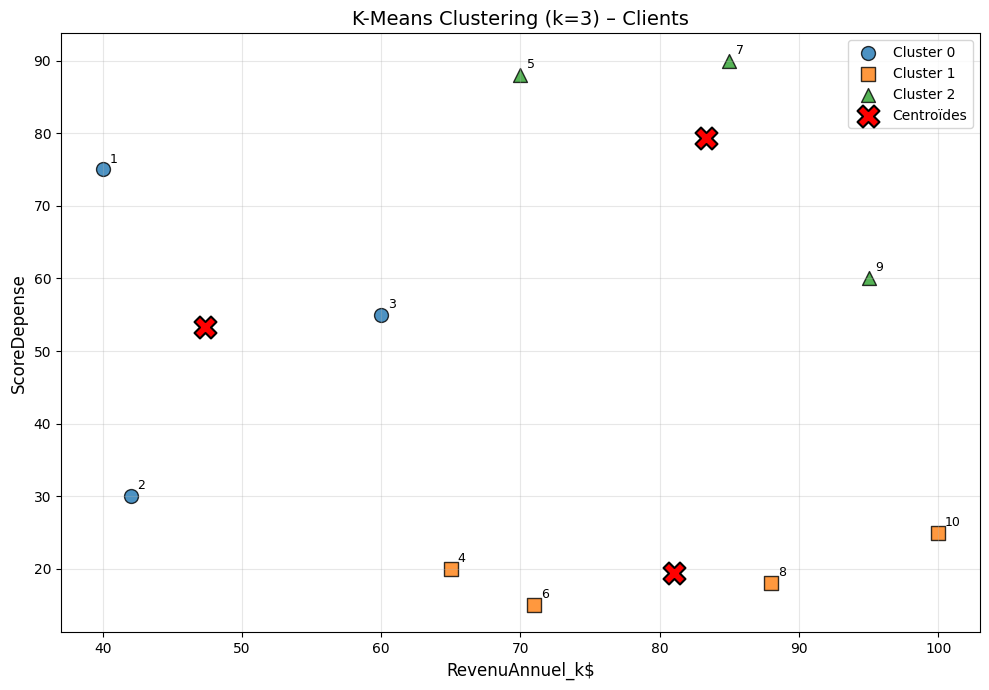

In [18]:
# c) Scatter plot
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for i in range(3):
    mask = labels == i
    plt.scatter(X_kmeans[mask, 0], X_kmeans[mask, 1],
                c=colors[i], marker=markers[i], s=100,
                label=f'Cluster {i}', edgecolors='k', alpha=0.8)

# Centroïdes
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250,
            label='Centroïdes', edgecolors='black', linewidths=1.5, zorder=5)

# Annotations des clients
for i, row in clients.iterrows():
    plt.annotate(str(row['ClientID']),
                 (row['RevenuAnnuel_k$'], row['ScoreDepense']),
                 textcoords="offset points", xytext=(5,5), fontsize=9)

plt.xlabel('RevenuAnnuel_k$', fontsize=12)
plt.ylabel('ScoreDepense', fontsize=12)
plt.title('K-Means Clustering (k=3) – Clients', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Question 2 - Prédiction pour un nouveau client

In [19]:
# Nouveau point
new_client = np.array([[75, 80]])

# Prédiction du cluster
predicted_cluster = kmeans.predict(new_client)[0]
print(f"Cluster prédit pour le nouveau client (75, 80) : Cluster {predicted_cluster}")

# Calcul des distances euclidiennes à chaque centroïde
print("\nDistances euclidiennes aux centroïdes :")
for i, c in enumerate(centroids):
    dist = np.linalg.norm(new_client - c)
    print(f"  Distance au centroïde du Cluster {i} ({c[0]:.2f}, {c[1]:.2f}) : {dist:.4f}")

print(f"\n→ Le point est le plus proche du Cluster {predicted_cluster} (distance minimale).")

Cluster prédit pour le nouveau client (75, 80) : Cluster 2

Distances euclidiennes aux centroïdes :
  Distance au centroïde du Cluster 0 (47.33, 53.33) : 38.4260
  Distance au centroïde du Cluster 1 (81.00, 19.50) : 60.7968
  Distance au centroïde du Cluster 2 (83.33, 79.33) : 8.3600

→ Le point est le plus proche du Cluster 2 (distance minimale).
